In [3]:
# 1. 라이브러리

import os
import numpy as np
import pandas as pd
from collections import defaultdict, Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import haversine_distances

import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

In [4]:
# 2. 4~8월 cargo CSV 로딩

file_paths = [
    r"C:\Users\win11\Desktop\prE\04cargo.csv",
    r"C:\Users\win11\Desktop\prE\05cargo.csv",
    r"C:\Users\win11\Desktop\prE\06cargo.csv",
    r"C:\Users\win11\Desktop\prE\07cargo.csv",
    r"C:\Users\win11\Desktop\prE\08cargo.csv",
]

df_list = []

for path in file_paths:
    temp = pd.read_csv(path)
    temp["source_file"] = os.path.basename(path)
    df_list.append(temp)

df_raw = pd.concat(df_list, ignore_index=True)

print(df_raw.shape)
print(df_raw.columns)
df_raw.head()

(4500839, 20)
Index(['MMSI', 'Date', 'Lat', 'Long', 'SOG', 'COG', 'Heading', 'Name', 'Type',
       'IMO', 'Call', 'DimA', 'DimB', 'DimC', 'DimD', 'Draft', 'Tons',
       'Length', 'Breadth', 'source_file'],
      dtype='object')


,MMSI,Date,Lat,Long,SOG,COG,Heading,Name,Type,IMO,Call,DimA,DimB,DimC,DimD,Draft,Tons,Length,Breadth,source_file
0,215331000,2024-04-01 00:02:56,35.067482,128.808068,0.0,285.7,78,CMA CGM ARGENTINA,70.0,9839909.0,9HA5066,110.0,256.0,29.0,22.0,14.4,169408.0,366.0,51.0,04cargo.csv
1,215331000,2024-04-01 00:05:56,35.067487,128.808107,0.0,233.2,78,CMA CGM ARGENTINA,70.0,9839909.0,9HA5066,110.0,256.0,29.0,22.0,14.4,169408.0,366.0,51.0,04cargo.csv
2,215331000,2024-04-01 00:08:56,35.067478,128.808130,0.0,236.5,78,CMA CGM ARGENTINA,70.0,9839909.0,9HA5066,110.0,256.0,29.0,22.0,14.4,169408.0,366.0,51.0,04cargo.csv
3,215331000,2024-04-01 00:11:56,35.067490,128.808120,0.0,242.4,78,CMA CGM ARGENTINA,70.0,9839909.0,9HA5066,110.0,256.0,29.0,22.0,14.4,169408.0,366.0,51.0,04cargo.csv
4,215331000,2024-04-01 00:14:56,35.067518,128.808348,0.0,238.9,78,CMA CGM ARGENTINA,70.0,9839909.0,9HA5066,110.0,256.0,29.0,22.0,14.4,169408.0,366.0,51.0,04cargo.csv


In [5]:
# 3. 컬럼 정리 및 기본 전처리

df = df_raw[["MMSI", "Date", "Lat", "Long", "SOG", "COG", "Heading", "source_file"]].copy()

df = df.rename(columns={
    "Date": "timestamp",
    "Lat": "lat",
    "Long": "lon",
    "SOG": "sog",
    "COG": "cog",
    "Heading": "heading"
})

df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

for col in ["lat", "lon", "sog", "cog", "heading"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["MMSI", "timestamp", "lat", "lon", "sog", "cog", "heading"])

df = df[
    (df["lat"].between(-90, 90)) &
    (df["lon"].between(-180, 180)) &
    (df["sog"] >= 0) &
    (df["cog"].between(0, 360)) &
    (df["heading"].between(0, 360))
].copy()

df = df.sort_values(["MMSI", "timestamp"]).reset_index(drop=True)

df["month"] = df["timestamp"].dt.month

print(df.shape)
print(df["month"].value_counts().sort_index())
df.head()

(4417967, 9)
4    826933
5    900471
6    907346
7    912136
8    871081
Name: month, dtype: int64


,MMSI,timestamp,lat,lon,sog,cog,heading,source_file,month
0,209079000,2024-08-05 03:42:22,34.960100,128.823167,9.9,339.7,338,08cargo.csv,8
1,209079000,2024-08-05 03:42:32,34.960518,128.822972,9.8,339.7,338,08cargo.csv,8
2,209079000,2024-08-05 03:42:42,34.960935,128.822775,9.6,339.1,338,08cargo.csv,8
3,209079000,2024-08-05 03:42:52,34.961335,128.822592,9.4,338.6,338,08cargo.csv,8
4,209079000,2024-08-05 03:43:02,34.961732,128.822387,9.3,338.0,338,08cargo.csv,8


In [6]:
# 4. 이동 선박 / 정지 선박 기준

MOVING_THRESHOLD = 0.5

moving_df = df[df["sog"] > MOVING_THRESHOLD].copy()
stationary_df = df[df["sog"] <= MOVING_THRESHOLD].copy()

print("전체 데이터:", len(df))
print("이동 선박 데이터:", len(moving_df))
print("정지/저속 선박 데이터:", len(stationary_df))

전체 데이터: 4417967
이동 선박 데이터: 2614784
정지/저속 선박 데이터: 1803183


In [64]:
# 5. Grid 설정
# Interaction Graph 학습용: 0.5 NM
# 최종 혼잡도 시각화용: 1.0 NM

TRAIN_GRID_NM = 0.5
VIS_GRID_NM = 1.0

BASE_LAT_FOR_LON_SCALE = 35.0

TRAIN_LAT_GRID_SIZE = (TRAIN_GRID_NM * 1.852) / 111
TRAIN_LON_GRID_SIZE = (TRAIN_GRID_NM * 1.852) / (
    111 * np.cos(np.radians(BASE_LAT_FOR_LON_SCALE))
)

VIS_LAT_GRID_SIZE = (VIS_GRID_NM * 1.852) / 111
VIS_LON_GRID_SIZE = (VIS_GRID_NM * 1.852) / (
    111 * np.cos(np.radians(BASE_LAT_FOR_LON_SCALE))
)

print("TRAIN_LAT_GRID_SIZE:", TRAIN_LAT_GRID_SIZE)
print("TRAIN_LON_GRID_SIZE:", TRAIN_LON_GRID_SIZE)
print("VIS_LAT_GRID_SIZE:", VIS_LAT_GRID_SIZE)
print("VIS_LON_GRID_SIZE:", VIS_LON_GRID_SIZE)

TRAIN_LAT_GRID_SIZE: 0.008342342342342343
TRAIN_LON_GRID_SIZE: 0.010184119542280256
VIS_LAT_GRID_SIZE: 0.016684684684684686
VIS_LON_GRID_SIZE: 0.02036823908456051


In [9]:
# 6. AIS 데이터를 5분 단위로 resampling
# 빠른 버전: lat/lon/sog/cog/heading 모두 단순 평균

RESAMPLE_INTERVAL = "5min"

def resample_ais_5min_fast(df):
    result = []

    numeric_cols = ["lat", "lon", "sog", "cog", "heading"]

    for mmsi, group in df.groupby("MMSI"):
        group = group.sort_values("timestamp").copy()
        group = group.set_index("timestamp")

        resampled = group[numeric_cols].resample(RESAMPLE_INTERVAL).mean()
        resampled = resampled.interpolate(method="linear")
        resampled = resampled.dropna()

        resampled["MMSI"] = mmsi
        resampled = resampled.reset_index()

        result.append(resampled)

    if len(result) == 0:
        return pd.DataFrame()

    return pd.concat(result, ignore_index=True)


moving_resampled = resample_ais_5min_fast(moving_df)
moving_resampled = moving_resampled.sort_values(["MMSI", "timestamp"]).reset_index(drop=True)
moving_resampled["month"] = moving_resampled["timestamp"].dt.month

print(moving_resampled.shape)
print(moving_resampled["month"].value_counts().sort_index())
moving_resampled.head()

(18278011, 8)
4    2123156
5    4480085
6    4987736
7    4468498
8    2218536
Name: month, dtype: int64


,timestamp,lat,lon,sog,cog,heading,MMSI,month
0,2024-08-05 03:40:00,34.963040,128.821752,8.925000,338.312500,339.125000,209079000,8
1,2024-08-05 03:45:00,34.970949,128.818051,7.906667,339.106667,340.633333,209079000,8
2,2024-08-05 03:50:00,34.983610,128.812304,11.553333,339.053333,338.666667,209079000,8
3,2024-08-05 03:55:00,34.999833,128.804516,13.063333,339.370000,339.066667,209079000,8
4,2024-08-05 04:00:00,35.019009,128.796003,13.377500,337.232500,331.850000,209079000,8


In [10]:
# 7. 월 기준 Train / Validation / Test 분리
# Train: 4~6월, Validation: 7월, Test: 8월

train_raw = moving_resampled[moving_resampled["month"].isin([4, 5, 6])].copy()
val_raw = moving_resampled[moving_resampled["month"].isin([7])].copy()
test_raw = moving_resampled[moving_resampled["month"].isin([8])].copy()

print("train_raw:", train_raw.shape)
print("val_raw:", val_raw.shape)
print("test_raw:", test_raw.shape)

train_raw: (11590977, 8)
val_raw: (4468498, 8)
test_raw: (2218536, 8)


In [11]:
# 8. 정규화
# scaler는 반드시 train_raw로만 fit
# val/test는 transform만 수행

feature_cols = ["lat", "lon", "sog", "cog", "heading"]
target_cols = ["lat", "lon"]

x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

x_scaler.fit(train_raw[feature_cols])
y_scaler.fit(train_raw[target_cols])


def apply_scaling(raw_df):
    norm_df = raw_df.copy()
    norm_df[feature_cols] = x_scaler.transform(raw_df[feature_cols])
    norm_df[target_cols] = y_scaler.transform(raw_df[target_cols])
    return norm_df


train_norm = apply_scaling(train_raw)
val_norm = apply_scaling(val_raw)
test_norm = apply_scaling(test_raw)

# 전체 예측용 norm 데이터
all_norm = apply_scaling(moving_resampled)

train_norm.head()

,timestamp,lat,lon,sog,cog,heading,MMSI,month
516,2024-04-15 10:35:00,0.002318,0.898242,0.095379,0.940278,0.947075,209423000,4
517,2024-04-15 10:40:00,0.058490,0.844810,0.093379,0.941954,0.947075,209423000,4
518,2024-04-15 10:45:00,0.160297,0.750063,0.081613,0.942333,0.947075,209423000,4
519,2024-04-15 10:50:00,0.252004,0.664034,0.076696,0.942269,0.947075,209423000,4
520,2024-04-15 10:55:00,0.346525,0.578389,0.086988,0.943074,0.947075,209423000,4


In [12]:
# 9. Interaction Graph 생성
# 반드시 train_raw로만 생성

def latlon_to_grid(lat, lon, lat_min, lon_min, lat_grid_size, lon_grid_size):
    row = int((lat - lat_min) / lat_grid_size)
    col = int((lon - lon_min) / lon_grid_size)
    return row, col


def build_interaction_counts(df):
    transition_counts = defaultdict(int)

    lat_min = df["lat"].min()
    lon_min = df["lon"].min()

    for mmsi, group in df.groupby("MMSI"):
        group = group.sort_values("timestamp")
        coords = group[["lat", "lon"]].values

        for i in range(len(coords) - 1):
            g1 = latlon_to_grid(
                coords[i][0],
                coords[i][1],
                lat_min,
                lon_min,
                TRAIN_LAT_GRID_SIZE,
                TRAIN_LON_GRID_SIZE
            )

            g2 = latlon_to_grid(
                coords[i + 1][0],
                coords[i + 1][1],
                lat_min,
                lon_min,
                TRAIN_LAT_GRID_SIZE,
                TRAIN_LON_GRID_SIZE
            )

            transition_counts[(g1, g2)] += 1

    return transition_counts, lat_min, lon_min


transition_counts, train_lat_min, train_lon_min = build_interaction_counts(train_raw)

print("interaction edge 수:", len(transition_counts))
print("train_lat_min:", train_lat_min)
print("train_lon_min:", train_lon_min)

interaction edge 수: 493
train_lat_min: 34.96
train_lon_min: 128.770005


In [13]:
# 10. Distance Graph + Interaction Graph 생성 함수

def create_distance_graph(raw_seq, sigma=0.1):
    coords = raw_seq[:, :2]
    dist = haversine_distances(np.radians(coords))
    A = np.exp(-dist / sigma)
    return A.astype(np.float32)


def create_interaction_graph(raw_seq):
    N = len(raw_seq)
    A = np.zeros((N, N), dtype=np.float32)

    nodes = [
        latlon_to_grid(
            lat,
            lon,
            train_lat_min,
            train_lon_min,
            TRAIN_LAT_GRID_SIZE,
            TRAIN_LON_GRID_SIZE
        )
        for lat, lon, sog, cog, heading in raw_seq
    ]

    for i in range(N):
        for j in range(N):
            A[i, j] = transition_counts.get((nodes[i], nodes[j]), 0)

    if A.max() > 0:
        A = A / (A.max() + 1e-6)

    return A.astype(np.float32)


def create_multi_graph(raw_seq):
    A_distance = create_distance_graph(raw_seq)
    A_interaction = create_interaction_graph(raw_seq)

    graphs = np.stack([A_distance, A_interaction], axis=0)

    return graphs.astype(np.float32)

In [16]:
# 11. 과거 10개 시점 → 다음 5분 위치 예측


def create_distance_graph_fast(raw_seq, sigma=1.0):
    coords = raw_seq[:, :2]

    lat = coords[:, 0]
    lon = coords[:, 1]

    lat_km = lat * 111
    lon_km = lon * 111 * np.cos(np.radians(35.0))

    xy = np.stack([lat_km, lon_km], axis=1)

    diff = xy[:, None, :] - xy[None, :, :]
    dist = np.sqrt(np.sum(diff ** 2, axis=-1))

    A = np.exp(-dist / sigma)

    return A.astype(np.float32)


def create_multi_graph_fast(raw_seq):
    A_distance = create_distance_graph_fast(raw_seq)
    A_interaction = create_interaction_graph(raw_seq)

    graphs = np.stack([A_distance, A_interaction], axis=0)

    return graphs.astype(np.float32)


def create_next_step_sequences_with_graph_fast(
    raw_df,
    norm_df,
    seq_len=10,
    stride=3,
    max_sequences=None
):
    sequences = []

    for mmsi in raw_df["MMSI"].unique():
        raw_group = raw_df[raw_df["MMSI"] == mmsi].sort_values("timestamp").reset_index(drop=True)
        norm_group = norm_df[norm_df["MMSI"] == mmsi].sort_values("timestamp").reset_index(drop=True)

        if len(raw_group) <= seq_len:
            continue

        raw_data = raw_group[feature_cols].values.astype(np.float32)
        norm_data = norm_group[feature_cols].values.astype(np.float32)

        for i in range(0, len(raw_group) - seq_len, stride):
            raw_seq = raw_data[i:i + seq_len]
            norm_seq = norm_data[i:i + seq_len]
            target = norm_data[i + seq_len][:2]

            graph = create_multi_graph_fast(raw_seq)

            sequences.append((norm_seq, graph, target))

            if max_sequences is not None and len(sequences) >= max_sequences:
                return sequences

    return sequences


SEQ_LEN = 10

TRAIN_STRIDE = 3
VAL_STRIDE = 5
TEST_STRIDE = 5

MAX_TRAIN_SEQUENCES = 200000
MAX_VAL_SEQUENCES = 50000
MAX_TEST_SEQUENCES = 50000

train_sequences = create_next_step_sequences_with_graph_fast(
    train_raw,
    train_norm,
    seq_len=SEQ_LEN,
    stride=TRAIN_STRIDE,
    max_sequences=MAX_TRAIN_SEQUENCES
)

val_sequences = create_next_step_sequences_with_graph_fast(
    val_raw,
    val_norm,
    seq_len=SEQ_LEN,
    stride=VAL_STRIDE,
    max_sequences=MAX_VAL_SEQUENCES
)

test_sequences = create_next_step_sequences_with_graph_fast(
    test_raw,
    test_norm,
    seq_len=SEQ_LEN,
    stride=TEST_STRIDE,
    max_sequences=MAX_TEST_SEQUENCES
)

print("train_sequences:", len(train_sequences))
print("val_sequences:", len(val_sequences))
print("test_sequences:", len(test_sequences))

print("sample norm_seq:", train_sequences[0][0].shape)
print("sample graph:", train_sequences[0][1].shape)
print("sample target:", train_sequences[0][2].shape)

train_sequences: 200000
val_sequences: 50000
test_sequences: 50000
sample norm_seq: (10, 5)
sample graph: (2, 10, 10)
sample target: (2,)


In [17]:
# 12. Dataset / DataLoader
# graph는 이미 pre-compute 되어 있음

class AISDataset(Dataset):
    def __init__(self, sequences):
        self.sequences = sequences

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        norm_seq, graph, target = self.sequences[idx]

        return (
            torch.tensor(norm_seq, dtype=torch.float32),
            torch.tensor(graph, dtype=torch.float32),
            torch.tensor(target, dtype=torch.float32)
        )


BATCH_SIZE = 32

train_dataset = AISDataset(train_sequences)
val_dataset = AISDataset(val_sequences)
test_dataset = AISDataset(test_sequences)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

for X, graphs, y in train_loader:
    print("X:", X.shape)
    print("graphs:", graphs.shape)
    print("y:", y.shape)
    break

X: torch.Size([32, 10, 5])
graphs: torch.Size([32, 2, 10, 10])
y: torch.Size([32, 2])


In [18]:
# 13. STMGNN 모델 정의

class GCNLayer(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.linear = nn.Linear(in_dim, out_dim)

    def forward(self, X, A):
        B, T, _ = X.shape

        I = torch.eye(T, device=X.device).unsqueeze(0).expand(B, T, T)
        A_hat = A + I

        degree = torch.sum(A_hat, dim=-1)
        degree_inv_sqrt = torch.pow(degree + 1e-6, -0.5)
        D_inv_sqrt = torch.diag_embed(degree_inv_sqrt)

        A_norm = D_inv_sqrt @ A_hat @ D_inv_sqrt

        XW = self.linear(X)
        out = A_norm @ XW

        return out


class GraphAttentionFusion(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.score_layer = nn.Linear(hidden_dim, 1)

    def forward(self, H_list):
        scores = []

        for H in H_list:
            score = self.score_layer(H).mean(dim=1)
            scores.append(score)

        scores = torch.cat(scores, dim=1)
        weights = F.softmax(scores, dim=1)

        fused = 0

        for i, H in enumerate(H_list):
            w = weights[:, i].view(-1, 1, 1)
            fused = fused + w * H

        return fused


class TemporalBlock(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()

        self.conv1 = nn.Conv1d(hidden_dim, hidden_dim, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(hidden_dim, hidden_dim, kernel_size=3, padding=1)
        self.norm = nn.LayerNorm(hidden_dim)

    def forward(self, x):
        residual = x

        x = x.permute(0, 2, 1)
        x = F.relu(self.conv1(x))
        x = self.conv2(x)
        x = x.permute(0, 2, 1)

        return self.norm(x + residual)


class STMGNN(nn.Module):
    def __init__(self, input_dim=5, hidden_dim=64, num_graphs=2, output_dim=2):
        super().__init__()

        self.num_graphs = num_graphs

        self.gcn_layers = nn.ModuleList([
            GCNLayer(input_dim, hidden_dim)
            for _ in range(num_graphs)
        ])

        self.fusion = GraphAttentionFusion(hidden_dim)

        self.temporal1 = TemporalBlock(hidden_dim)
        self.temporal2 = TemporalBlock(hidden_dim)

        self.output_layer = nn.Linear(hidden_dim, output_dim)

    def forward(self, X, graphs):
        H_list = []

        for i in range(self.num_graphs):
            A = graphs[:, i, :, :]
            H = self.gcn_layers[i](X, A)
            H_list.append(H)

        H = self.fusion(H_list)
        H = self.temporal1(H)
        H = self.temporal2(H)

        last_hidden = H[:, -1, :]

        out = self.output_layer(last_hidden)

        return out

In [19]:
# 14. 학습 준비

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

model = STMGNN(
    input_dim=5,
    hidden_dim=64,
    num_graphs=2,
    output_dim=2
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

device: cpu


In [20]:
# 15. 학습 함수 + Validation 함수 + Early Stopping

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0

    for X, graphs, y in loader:
        X = X.to(device)
        graphs = graphs.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        pred = model(X, graphs)
        loss = criterion(pred, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def evaluate_loss(model, loader, criterion):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for X, graphs, y in loader:
            X = X.to(device)
            graphs = graphs.to(device)
            y = y.to(device)

            pred = model(X, graphs)
            loss = criterion(pred, y)

            total_loss += loss.item()

    return total_loss / len(loader)


EPOCHS = 50
PATIENCE = 7

best_val_loss = float("inf")
patience_counter = 0
best_model_state = None

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss = evaluate_loss(model, val_loader, criterion)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch [{epoch+1}/{EPOCHS}] Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict()
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= PATIENCE:
        print("Early stopping")
        break

if best_model_state is not None:
    model.load_state_dict(best_model_state)

print("Best Val Loss:", best_val_loss)

Epoch [1/50] Train Loss: 0.000341 | Val Loss: 0.000080
Epoch [2/50] Train Loss: 0.000049 | Val Loss: 0.000023
Epoch [3/50] Train Loss: 0.000032 | Val Loss: 0.000027
Epoch [4/50] Train Loss: 0.000026 | Val Loss: 0.000020
Epoch [5/50] Train Loss: 0.000024 | Val Loss: 0.000018
Epoch [6/50] Train Loss: 0.000020 | Val Loss: 0.000009
Epoch [7/50] Train Loss: 0.000019 | Val Loss: 0.000014
Epoch [8/50] Train Loss: 0.000017 | Val Loss: 0.000030
Epoch [9/50] Train Loss: 0.000016 | Val Loss: 0.000016
Epoch [10/50] Train Loss: 0.000015 | Val Loss: 0.000023
Epoch [11/50] Train Loss: 0.000014 | Val Loss: 0.000010
Epoch [12/50] Train Loss: 0.000013 | Val Loss: 0.000016
Epoch [13/50] Train Loss: 0.000014 | Val Loss: 0.000011
Early stopping
Best Val Loss: 8.66446494388758e-06


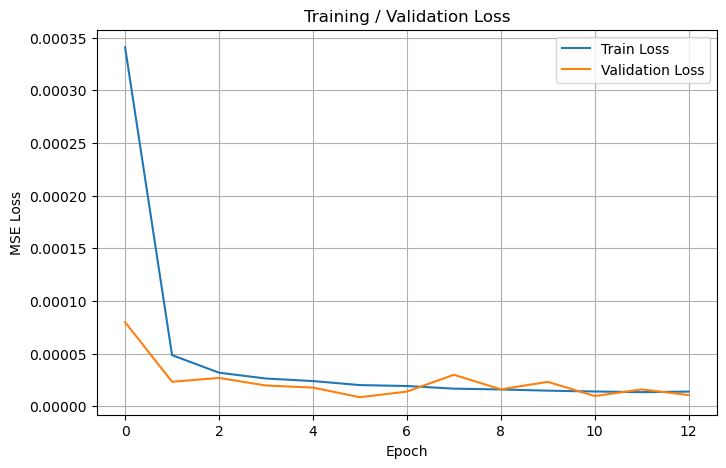

In [21]:
# 16. 학습 곡선 확인

plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training / Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [22]:
# 17. Test set 다음 5분 위치 예측 확인

model.eval()

with torch.no_grad():
    for X, graphs, y in test_loader:
        X = X.to(device)
        graphs = graphs.to(device)
        y = y.to(device)

        pred = model(X, graphs)

        pred_original = y_scaler.inverse_transform(pred.cpu().numpy())
        true_original = y_scaler.inverse_transform(y.cpu().numpy())

        print("예측값 Lat/Lon:")
        print(pred_original[:5])

        print("실제값 Lat/Lon:")
        print(true_original[:5])

        break

예측값 Lat/Lon:
[[ 35.036488 128.77354 ]
 [ 35.030525 128.77312 ]
 [ 35.030315 128.77298 ]
 [ 35.030277 128.77298 ]
 [ 35.03024  128.77298 ]]
실제값 Lat/Lon:
[[ 35.035076 128.77046 ]
 [ 35.035    128.77048 ]
 [ 35.034916 128.77051 ]
 [ 35.034836 128.77052 ]
 [ 35.03476  128.77054 ]]


In [23]:
# 18. 예측/평가용 함수 정의

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    )

    c = 2 * np.arcsin(np.sqrt(a))

    return R * c


def assign_visual_grid(lat, lon, lat_min, lon_min):
    row = int((lat - lat_min) / VIS_LAT_GRID_SIZE)
    col = int((lon - lon_min) / VIS_LON_GRID_SIZE)
    return row, col


def make_grid_count_from_positions(positions, lat_min, lon_min):
    grid_counter = Counter()

    for lat, lon in positions:
        if np.isnan(lat) or np.isnan(lon):
            continue

        grid = assign_visual_grid(lat, lon, lat_min, lon_min)
        grid_counter[grid] += 1

    return grid_counter


def evaluate_grid_congestion(pred_grid_count, actual_grid_count, top_k=5):
    all_grids = sorted(set(pred_grid_count.keys()) | set(actual_grid_count.keys()))

    if len(all_grids) == 0:
        return None

    pred_counts = np.array([pred_grid_count.get(g, 0) for g in all_grids], dtype=float)
    actual_counts = np.array([actual_grid_count.get(g, 0) for g in all_grids], dtype=float)

    mae = np.mean(np.abs(pred_counts - actual_counts))
    rmse = np.sqrt(np.mean((pred_counts - actual_counts) ** 2))

    nonzero_mask = actual_counts > 0

    if nonzero_mask.sum() > 0:
        mape = np.mean(
            np.abs(
                (actual_counts[nonzero_mask] - pred_counts[nonzero_mask])
                / actual_counts[nonzero_mask]
            )
        ) * 100
    else:
        mape = np.nan

    if len(actual_counts) > 1 and np.std(actual_counts) > 0 and np.std(pred_counts) > 0:
        corr = np.corrcoef(actual_counts, pred_counts)[0, 1]
    else:
        corr = np.nan

    actual_top_k = set([all_grids[i] for i in np.argsort(actual_counts)[::-1][:top_k]])
    pred_top_k = set([all_grids[i] for i in np.argsort(pred_counts)[::-1][:top_k]])

    top_k_overlap = len(actual_top_k & pred_top_k)
    top_k_accuracy = top_k_overlap / top_k

    return {
        "grid_count": len(all_grids),
        "grid_mae": mae,
        "grid_rmse": rmse,
        "grid_mape_percent": mape,
        "pearson_correlation": corr,
        f"top_{top_k}_overlap": top_k_overlap,
        f"top_{top_k}_accuracy": top_k_accuracy
    }


def predict_next_position(model, raw_seq, norm_seq):
    graph = create_multi_graph(raw_seq)

    X = torch.tensor(norm_seq, dtype=torch.float32).unsqueeze(0).to(device)
    graphs = torch.tensor(graph, dtype=torch.float32).unsqueeze(0).to(device)

    with torch.no_grad():
        pred_norm = model(X, graphs).cpu().numpy()

    pred_latlon = y_scaler.inverse_transform(pred_norm)[0]

    return pred_norm[0], pred_latlon


def recursive_forecast_single_vessel(model, raw_seq, norm_seq, forecast_minutes):
    steps = int(forecast_minutes / 5)

    raw_seq = raw_seq.copy()
    norm_seq = norm_seq.copy()

    for _ in range(steps):
        pred_norm_latlon, pred_latlon = predict_next_position(model, raw_seq, norm_seq)

        last_raw = raw_seq[-1].copy()
        last_norm = norm_seq[-1].copy()

        new_raw = last_raw.copy()
        new_raw[0] = pred_latlon[0]
        new_raw[1] = pred_latlon[1]

        new_norm = last_norm.copy()
        new_norm[0] = pred_norm_latlon[0]
        new_norm[1] = pred_norm_latlon[1]

        raw_seq = np.vstack([raw_seq[1:], new_raw])
        norm_seq = np.vstack([norm_seq[1:], new_norm])

    return raw_seq[-1, :2]

In [24]:
# 19. 여러 base_time 생성 및 입력 생성 함수

def generate_base_times(df, forecast_minutes, num_base_times=20):
    all_times = sorted(df["timestamp"].unique())

    max_allowed_time = df["timestamp"].max() - pd.Timedelta(minutes=forecast_minutes)

    candidate_times = [
        t for t in all_times
        if t <= max_allowed_time
    ]

    if len(candidate_times) == 0:
        raise ValueError("forecast_minutes 이후 실제값이 존재하는 base_time이 없습니다.")

    if len(candidate_times) <= num_base_times:
        return candidate_times

    selected_idx = np.linspace(
        0,
        len(candidate_times) - 1,
        num_base_times
    ).astype(int)

    return [candidate_times[i] for i in selected_idx]


def make_prediction_inputs_at_base_time(df_raw, df_norm, base_time, seq_len=10):
    pred_inputs = []
    vessel_ids = []

    current_df = df_raw[df_raw["timestamp"] <= base_time].copy()

    if len(current_df) == 0:
        return pred_inputs, vessel_ids

    latest_idx = current_df.groupby("MMSI")["timestamp"].idxmax()
    current_snapshot = current_df.loc[latest_idx].copy()

    moving_snapshot = current_snapshot[current_snapshot["sog"] > MOVING_THRESHOLD].copy()

    for _, row in moving_snapshot.iterrows():
        mmsi = row["MMSI"]
        t = row["timestamp"]

        hist_raw = df_raw[
            (df_raw["MMSI"] == mmsi) &
            (df_raw["timestamp"] <= t)
        ].sort_values("timestamp").tail(seq_len)

        hist_norm = df_norm[
            (df_norm["MMSI"] == mmsi) &
            (df_norm["timestamp"] <= t)
        ].sort_values("timestamp").tail(seq_len)

        if len(hist_raw) < seq_len or len(hist_norm) < seq_len:
            continue

        raw_seq = hist_raw[feature_cols].values.astype(np.float32)
        norm_seq = hist_norm[feature_cols].values.astype(np.float32)

        pred_inputs.append((raw_seq, norm_seq))
        vessel_ids.append(mmsi)

    return pred_inputs, vessel_ids


def get_actual_future_positions(df, vessel_ids, base_time, forecast_minutes):
    actual_positions = []

    target_time = base_time + pd.Timedelta(minutes=forecast_minutes)

    for mmsi in vessel_ids:
        vessel_data = df[
            (df["MMSI"] == mmsi) &
            (df["timestamp"] >= target_time)
        ].sort_values("timestamp")

        if len(vessel_data) == 0:
            actual_positions.append([np.nan, np.nan])
            continue

        actual_row = vessel_data.iloc[0]

        actual_positions.append([
            actual_row["lat"],
            actual_row["lon"]
        ])

    return np.array(actual_positions)


def get_actual_all_positions_at_future_time(df, base_time, forecast_minutes):
    target_time = base_time + pd.Timedelta(minutes=forecast_minutes)

    future_df = df[df["timestamp"] >= target_time].copy()

    if len(future_df) == 0:
        return np.empty((0, 2))

    latest_idx = future_df.groupby("MMSI")["timestamp"].idxmin()
    future_snapshot = future_df.loc[latest_idx].copy()

    return future_snapshot[["lat", "lon"]].values


def get_stationary_snapshot_at_base_time(df, base_time):
    current_df = df[df["timestamp"] <= base_time].copy()

    if len(current_df) == 0:
        return pd.DataFrame()

    latest_idx = current_df.groupby("MMSI")["timestamp"].idxmax()
    current_snapshot = current_df.loc[latest_idx].copy()

    stationary_snapshot = current_snapshot[
        current_snapshot["sog"] <= MOVING_THRESHOLD
    ].copy()

    return stationary_snapshot

In [25]:
# 20. 여러 base_time에 대해 예측/평가 실행
# Test 월인 8월 기준으로 평가

forecast_minutes = 10 
NUM_BASE_TIMES = 15

base_times = generate_base_times(
    test_raw,
    forecast_minutes=forecast_minutes,
    num_base_times=NUM_BASE_TIMES
)

print("base_time 개수:", len(base_times))
print(base_times[:5])

vis_grid_lat_min = df["lat"].min()
vis_grid_lon_min = df["lon"].min()

trajectory_results = []
grid_results = []
all_error_distances = []
prediction_visualization_data = []

model.eval()

for idx, base_time in enumerate(base_times):
    print(f"[{idx+1}/{len(base_times)}] base_time:", base_time)

    pred_inputs, vessel_ids = make_prediction_inputs_at_base_time(
        moving_resampled,
        all_norm,
        base_time,
        seq_len=SEQ_LEN
    )

    if len(pred_inputs) == 0:
        print("예측 가능한 이동 선박 없음. skip")
        continue

    predicted_positions = []

    for raw_seq, norm_seq in pred_inputs:
        future_latlon = recursive_forecast_single_vessel(
            model,
            raw_seq,
            norm_seq,
            forecast_minutes=forecast_minutes
        )
        predicted_positions.append(future_latlon)

    predicted_positions = np.array(predicted_positions)

    actual_positions = get_actual_future_positions(
        moving_resampled,
        vessel_ids,
        base_time,
        forecast_minutes
    )

    valid_mask = ~np.isnan(actual_positions).any(axis=1)

    if valid_mask.sum() == 0:
        print("실제 비교 위치 없음. skip")
        continue

    pred_valid = predicted_positions[valid_mask]
    actual_valid = actual_positions[valid_mask]

    errors_km = haversine_km(
        actual_valid[:, 0],
        actual_valid[:, 1],
        pred_valid[:, 0],
        pred_valid[:, 1]
    )

    all_error_distances.extend(errors_km.tolist())

    trajectory_results.append({
        "base_time": base_time,
        "forecast_minutes": forecast_minutes,
        "valid_ship_count": len(actual_valid),
        "mean_error_km": np.mean(errors_km),
        "median_error_km": np.median(errors_km),
        "p90_error_km": np.percentile(errors_km, 90),
        "max_error_km": np.max(errors_km),
        "mean_error_nm": np.mean(errors_km) / 1.852,
        "median_error_nm": np.median(errors_km) / 1.852,
        "p90_error_nm": np.percentile(errors_km, 90) / 1.852,
        "max_error_nm": np.max(errors_km) / 1.852,
    })

    # 예측 밀도: 예측 이동 선박 + 현재 정지/저속 선박 유지 가정
    stationary_snapshot = get_stationary_snapshot_at_base_time(df, base_time)

    pred_moving_grid_count = make_grid_count_from_positions(
        pred_valid,
        vis_grid_lat_min,
        vis_grid_lon_min
    )

    stationary_grid_count = Counter()

    for _, row in stationary_snapshot.iterrows():
        grid = assign_visual_grid(
            row["lat"],
            row["lon"],
            vis_grid_lat_min,
            vis_grid_lon_min
        )
        stationary_grid_count[grid] += 1

    pred_total_grid_count = Counter(pred_moving_grid_count)
    pred_total_grid_count.update(stationary_grid_count)

    # 실제 밀도: forecast 시점 이후 실제 관측 위치 전체
    actual_all_positions = get_actual_all_positions_at_future_time(
        df,
        base_time,
        forecast_minutes
    )

    actual_total_grid_count = make_grid_count_from_positions(
        actual_all_positions,
        vis_grid_lat_min,
        vis_grid_lon_min
    )

    grid_result = evaluate_grid_congestion(
        pred_total_grid_count,
        actual_total_grid_count,
        top_k=5
    )

    if grid_result is not None:
        grid_result["base_time"] = base_time
        grid_result["forecast_minutes"] = forecast_minutes
        grid_results.append(grid_result)

        prediction_visualization_data.append({
            "base_time": base_time,
            "forecast_minutes": forecast_minutes,
            "pred_valid": pred_valid.copy(),
            "actual_valid": actual_valid.copy(),
            "pred_grid_count": pred_total_grid_count.copy(),
            "actual_grid_count": actual_total_grid_count.copy()
        })

print("완료")
print("시각화 가능한 base_time 수:", len(prediction_visualization_data))

base_time 개수: 15
[numpy.datetime64('2024-08-01T00:00:00.000000000'), numpy.datetime64('2024-08-03T05:05:00.000000000'), numpy.datetime64('2024-08-05T10:15:00.000000000'), numpy.datetime64('2024-08-07T15:20:00.000000000'), numpy.datetime64('2024-08-09T20:30:00.000000000')]
[1/15] base_time: 2024-08-01T00:00:00.000000000
[2/15] base_time: 2024-08-03T05:05:00.000000000
[3/15] base_time: 2024-08-05T10:15:00.000000000
[4/15] base_time: 2024-08-07T15:20:00.000000000
[5/15] base_time: 2024-08-09T20:30:00.000000000
[6/15] base_time: 2024-08-12T01:35:00.000000000
[7/15] base_time: 2024-08-14T06:45:00.000000000
[8/15] base_time: 2024-08-16T11:50:00.000000000
[9/15] base_time: 2024-08-18T17:00:00.000000000
[10/15] base_time: 2024-08-20T22:05:00.000000000
[11/15] base_time: 2024-08-23T03:15:00.000000000
[12/15] base_time: 2024-08-25T08:20:00.000000000
[13/15] base_time: 2024-08-27T13:30:00.000000000
[14/15] base_time: 2024-08-29T18:35:00.000000000
[15/15] base_time: 2024-08-31T23:45:00.000000000
완

In [27]:
# 21. 성능평가 요약표 

trajectory_results_df = pd.DataFrame(trajectory_results)
grid_results_df = pd.DataFrame(grid_results)

print("trajectory_results:", trajectory_results_df.shape)
print("grid_results:", grid_results_df.shape)

if len(trajectory_results_df) > 0:
    trajectory_summary_df = trajectory_results_df[
        [
            "valid_ship_count",
            "mean_error_km",
            "median_error_km",
            "p90_error_km",
            "mean_error_nm",
            "median_error_nm",
            "p90_error_nm"
        ]
    ].mean(numeric_only=True).to_frame().T

    trajectory_summary_df.insert(0, "forecast_minutes", forecast_minutes)
    trajectory_summary_df.insert(1, "base_time_count", len(trajectory_results_df))
    trajectory_summary_df.insert(2, "total_valid_ship_count", trajectory_results_df["valid_ship_count"].sum())

    print("Trajectory-level Summary")
    display(trajectory_summary_df)
else:
    print("trajectory 결과 없음")


if len(grid_results_df) > 0:
    grid_summary_df = grid_results_df[
        [
            "grid_mae",
            "grid_rmse",
            "grid_mape_percent",
            "pearson_correlation",
            "top_5_accuracy"
        ]
    ].mean(numeric_only=True).to_frame().T

    grid_summary_df.insert(0, "forecast_minutes", forecast_minutes)
    grid_summary_df.insert(1, "base_time_count", len(grid_results_df))

    print("Grid-level Summary")
    display(grid_summary_df)
else:
    print("grid 결과 없음")

trajectory_results: (2, 11)
grid_results: (2, 9)
Trajectory-level Summary


,forecast_minutes,base_time_count,total_valid_ship_count,valid_ship_count,mean_error_km,median_error_km,p90_error_km,mean_error_nm,median_error_nm,p90_error_nm
0,15,2,788,394.0,0.080419,0.026034,0.068748,0.043423,0.014057,0.037121


Grid-level Summary


,forecast_minutes,base_time_count,grid_mae,grid_rmse,grid_mape_percent,pearson_correlation,top_5_accuracy
0,15,2,13.066667,34.383168,97.304898,0.997388,0.5


In [28]:
# 22. 저장된 base_time 목록 확인

print("저장된 base_time 개수:", len(prediction_visualization_data))

for i, item in enumerate(prediction_visualization_data):
    print(i, item["base_time"])

저장된 base_time 개수: 2
0 2024-08-01T00:00:00.000000000
1 2024-08-02T15:05:00.000000000


In [29]:
# 23. 시각화할 base_time 선택

VIS_IDX = 0   # 보고 싶은 번호로 변경

vis_data = prediction_visualization_data[VIS_IDX]

selected_base_time = vis_data["base_time"]
selected_forecast_minutes = vis_data["forecast_minutes"]

pred_valid = vis_data["pred_valid"]
actual_valid = vis_data["actual_valid"]

pred_grid_count = vis_data["pred_grid_count"]
actual_grid_count = vis_data["actual_grid_count"]

print("선택 base_time:", selected_base_time)
print("forecast_minutes:", selected_forecast_minutes)
print("비교 선박 수:", len(pred_valid))

선택 base_time: 2024-08-01T00:00:00.000000000
forecast_minutes: 15
비교 선박 수: 404


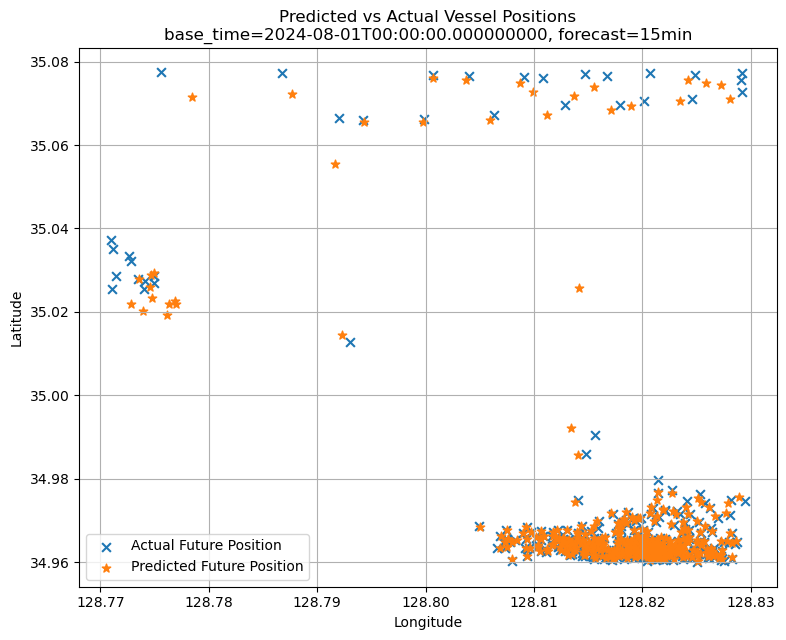

In [30]:
# 24. 예측 위치 vs 실제 위치 산점도

plt.figure(figsize=(9, 7))

plt.scatter(
    actual_valid[:, 1],
    actual_valid[:, 0],
    s=40,
    marker="x",
    label="Actual Future Position"
)

plt.scatter(
    pred_valid[:, 1],
    pred_valid[:, 0],
    s=40,
    marker="*",
    label="Predicted Future Position"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(
    f"Predicted vs Actual Vessel Positions\n"
    f"base_time={selected_base_time}, forecast={selected_forecast_minutes}min"
)
plt.legend()
plt.grid(True)

ax = plt.gca()
ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax.ticklabel_format(style="plain", axis="both")

plt.show()

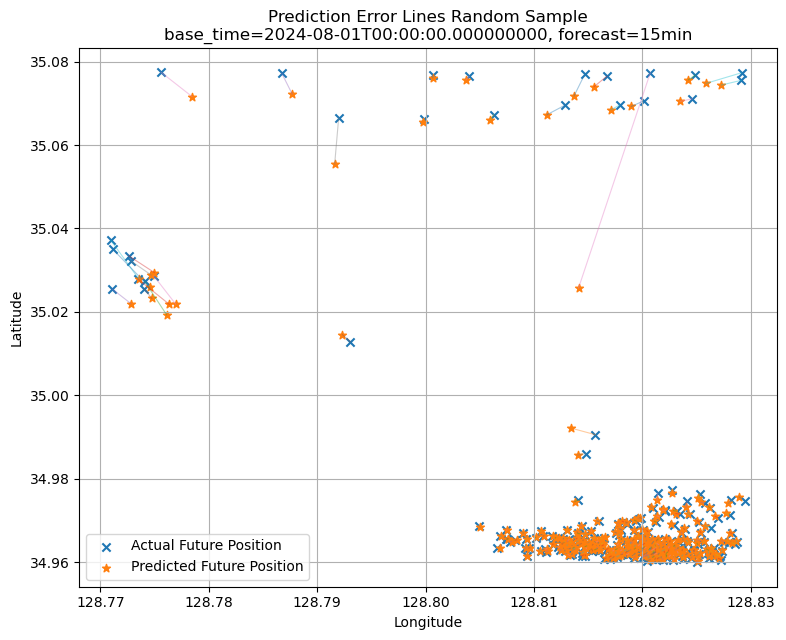

In [31]:
# 25. 실제 위치와 예측 위치 연결선
# 랜덤 샘플링

MAX_PLOT = 300
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)

plot_count = min(len(actual_valid), MAX_PLOT)

plot_idx = np.random.choice(
    np.arange(len(actual_valid)),
    size=plot_count,
    replace=False
)

plt.figure(figsize=(9, 7))

for i in plot_idx:
    plt.plot(
        [actual_valid[i, 1], pred_valid[i, 1]],
        [actual_valid[i, 0], pred_valid[i, 0]],
        linewidth=0.8,
        alpha=0.4
    )

plt.scatter(
    actual_valid[plot_idx, 1],
    actual_valid[plot_idx, 0],
    s=35,
    marker="x",
    label="Actual Future Position"
)

plt.scatter(
    pred_valid[plot_idx, 1],
    pred_valid[plot_idx, 0],
    s=35,
    marker="*",
    label="Predicted Future Position"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(
    f"Prediction Error Lines Random Sample\n"
    f"base_time={selected_base_time}, forecast={selected_forecast_minutes}min"
)
plt.legend()
plt.grid(True)

ax = plt.gca()
ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax.ticklabel_format(style="plain", axis="both")

plt.show()

In [32]:
# 26. Heatmap 변환 함수

def grid_count_to_heatmap(grid_count):
    if len(grid_count) == 0:
        return np.zeros((1, 1))

    max_row = max([g[0] for g in grid_count.keys()])
    max_col = max([g[1] for g in grid_count.keys()])

    heatmap = np.zeros((max_row + 1, max_col + 1))

    for grid, count in grid_count.items():
        heatmap[grid[0], grid[1]] = count

    return heatmap


actual_heatmap = grid_count_to_heatmap(actual_grid_count)
pred_heatmap = grid_count_to_heatmap(pred_grid_count)

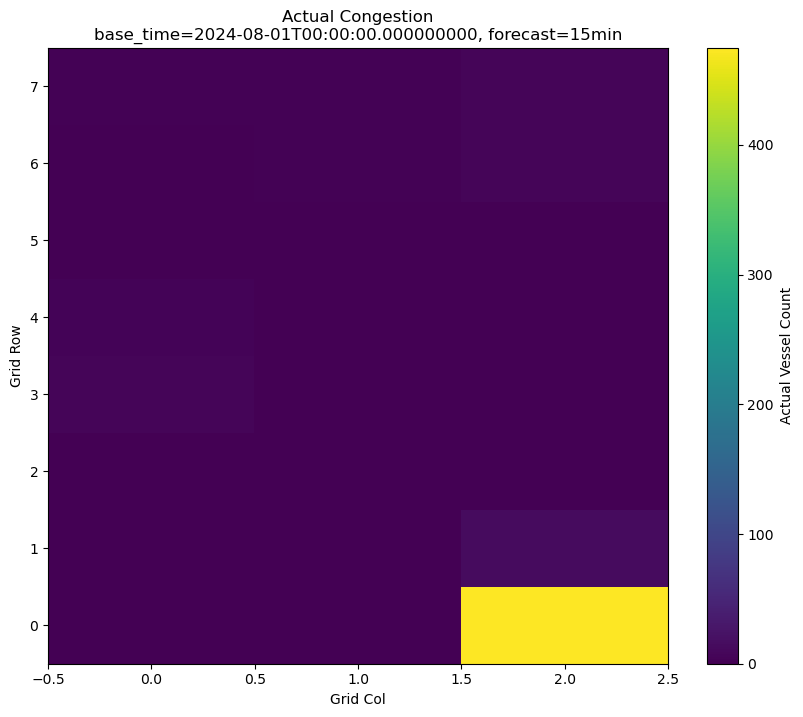

In [33]:
# 27. 실제 혼잡도 Heatmap

plt.figure(figsize=(10, 8))

plt.imshow(
    actual_heatmap,
    origin="lower",
    aspect="auto"
)

plt.colorbar(label="Actual Vessel Count")
plt.xlabel("Grid Col")
plt.ylabel("Grid Row")
plt.title(
    f"Actual Congestion\n"
    f"base_time={selected_base_time}, forecast={selected_forecast_minutes}min"
)

plt.show()

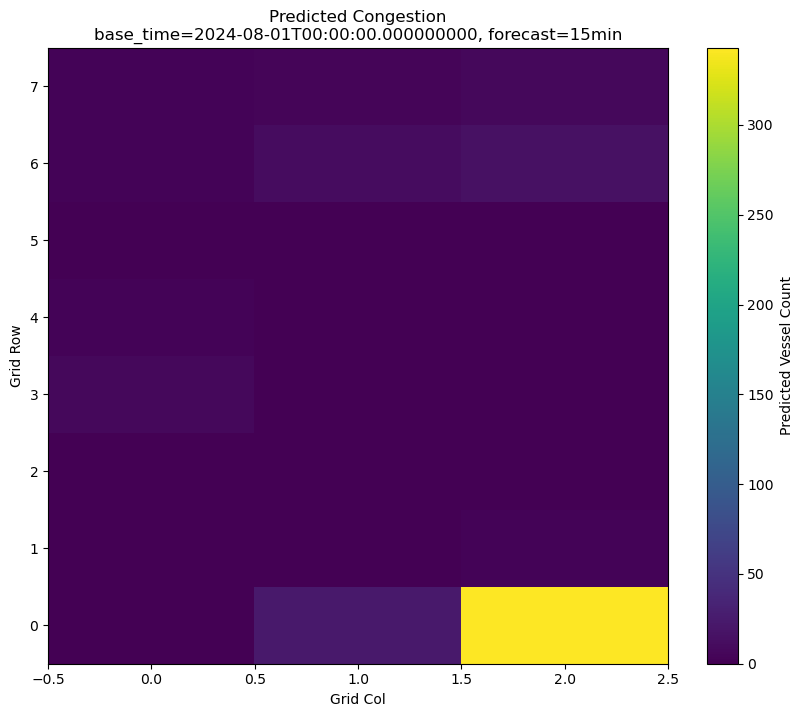

In [34]:
# 28. 예측 혼잡도 Heatmap

plt.figure(figsize=(10, 8))

plt.imshow(
    pred_heatmap,
    origin="lower",
    aspect="auto"
)

plt.colorbar(label="Predicted Vessel Count")
plt.xlabel("Grid Col")
plt.ylabel("Grid Row")
plt.title(
    f"Predicted Congestion\n"
    f"base_time={selected_base_time}, forecast={selected_forecast_minutes}min"
)

plt.show()

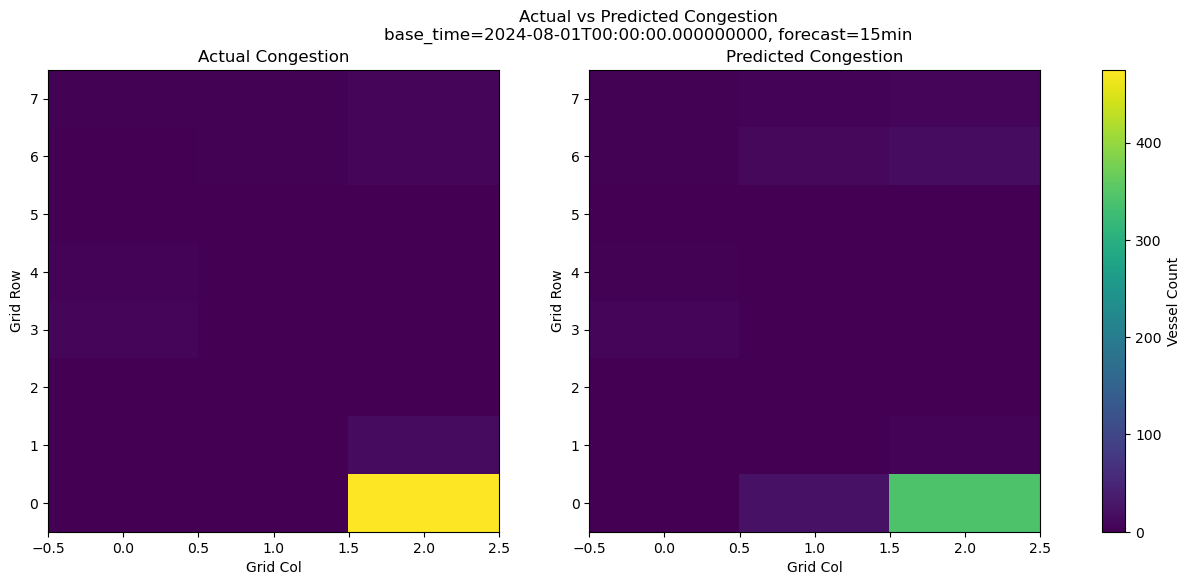

In [35]:
# 29. 실제 vs 예측 혼잡도 비교

max_row = max(actual_heatmap.shape[0], pred_heatmap.shape[0])
max_col = max(actual_heatmap.shape[1], pred_heatmap.shape[1])

actual_pad = np.zeros((max_row, max_col))
pred_pad = np.zeros((max_row, max_col))

actual_pad[:actual_heatmap.shape[0], :actual_heatmap.shape[1]] = actual_heatmap
pred_pad[:pred_heatmap.shape[0], :pred_heatmap.shape[1]] = pred_heatmap

vmax = max(actual_pad.max(), pred_pad.max())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

im0 = axes[0].imshow(
    actual_pad,
    origin="lower",
    aspect="auto",
    vmin=0,
    vmax=vmax
)
axes[0].set_title("Actual Congestion")
axes[0].set_xlabel("Grid Col")
axes[0].set_ylabel("Grid Row")

im1 = axes[1].imshow(
    pred_pad,
    origin="lower",
    aspect="auto",
    vmin=0,
    vmax=vmax
)
axes[1].set_title("Predicted Congestion")
axes[1].set_xlabel("Grid Col")
axes[1].set_ylabel("Grid Row")

fig.colorbar(im1, ax=axes.ravel().tolist(), label="Vessel Count")

plt.suptitle(
    f"Actual vs Predicted Congestion\n"
    f"base_time={selected_base_time}, forecast={selected_forecast_minutes}min"
)

plt.show()

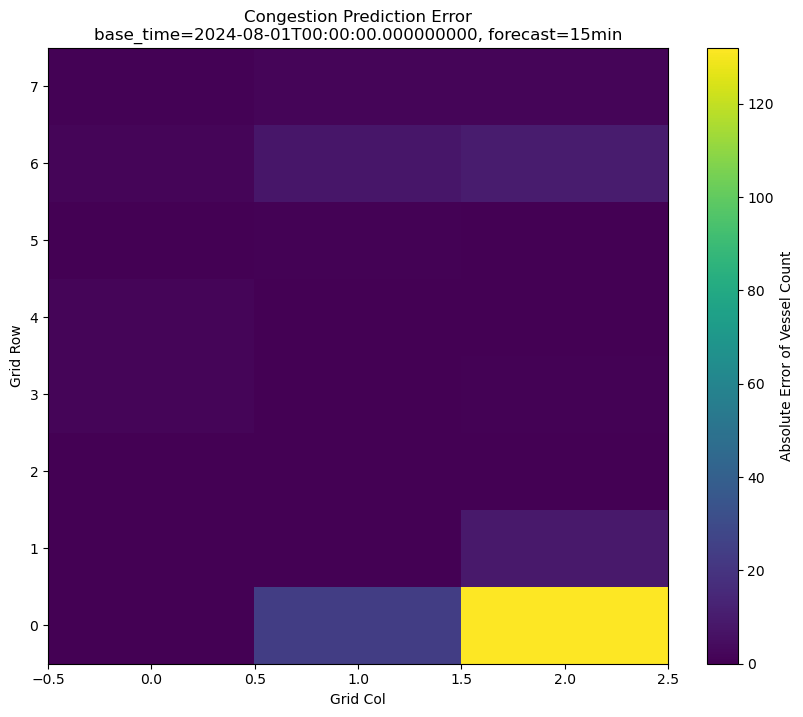

In [36]:
# 30. 혼잡도 오차 Heatmap

error_heatmap = np.abs(pred_pad - actual_pad)

plt.figure(figsize=(10, 8))

plt.imshow(
    error_heatmap,
    origin="lower",
    aspect="auto"
)

plt.colorbar(label="Absolute Error of Vessel Count")
plt.xlabel("Grid Col")
plt.ylabel("Grid Row")
plt.title(
    f"Congestion Prediction Error\n"
    f"base_time={selected_base_time}, forecast={selected_forecast_minutes}min"
)

plt.show()

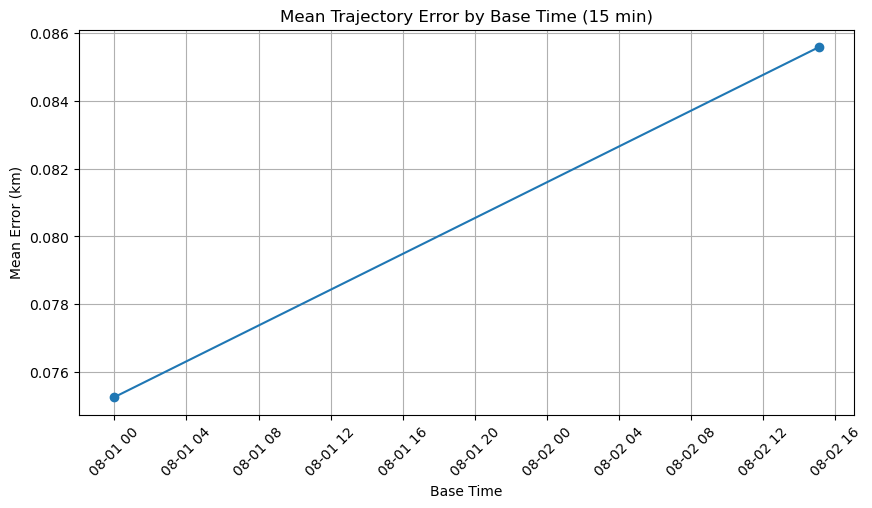

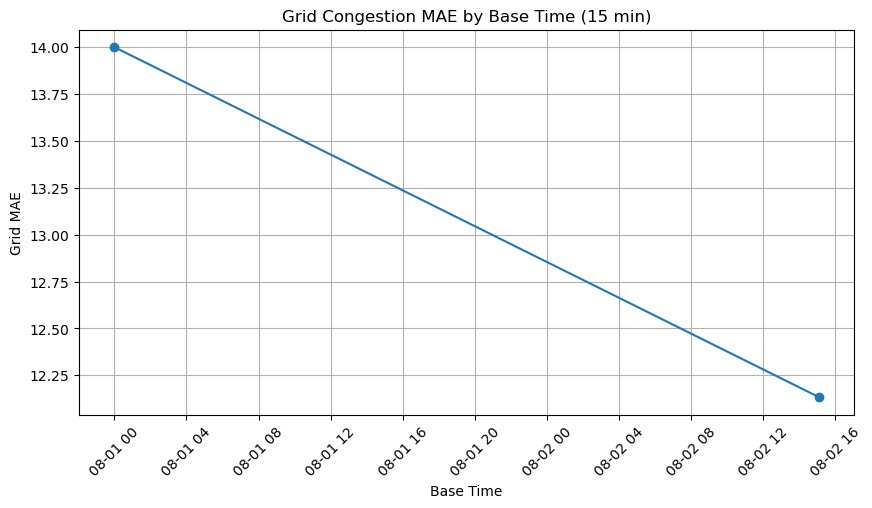

In [37]:
# 31. 여러 base_time 성능 변화 그래프

plt.figure(figsize=(10, 5))

plt.plot(
    trajectory_results_df["base_time"],
    trajectory_results_df["mean_error_km"],
    marker="o"
)

plt.xlabel("Base Time")
plt.ylabel("Mean Error (km)")
plt.title(f"Mean Trajectory Error by Base Time ({forecast_minutes} min)")
plt.grid(True)
plt.xticks(rotation=45)
plt.show()


plt.figure(figsize=(10, 5))

plt.plot(
    grid_results_df["base_time"],
    grid_results_df["grid_mae"],
    marker="o"
)

plt.xlabel("Base Time")
plt.ylabel("Grid MAE")
plt.title(f"Grid Congestion MAE by Base Time ({forecast_minutes} min)")
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

In [39]:
!pip install folium

     -------------------------------------- 113.4/113.4 kB 3.3 MB/s eta 0:00:00
     ---------------------------------------- 94.1/94.1 kB 1.8 MB/s eta 0:00:00


In [41]:
count_col = f"predicted_count_{selected_forecast_minutes}min"

future_grid_df = pd.DataFrame([
    {
        "grid_row": k[0],
        "grid_col": k[1],
        count_col: v
    }
    for k, v in pred_grid_count.items()
])

future_grid_df = future_grid_df.sort_values(
    count_col,
    ascending=False
).reset_index(drop=True)

future_grid_df.head()

,grid_row,grid_col,predicted_count_15min
0,0,2,343
1,0,1,24
2,6,2,16
3,6,1,11
4,3,0,8


In [65]:
import folium
import branca.colormap as cm

# 지도 중심
center_lat = df["lat"].mean()
center_lon = df["lon"].mean()

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=12,
    tiles="OpenStreetMap"
)

count_col = f"predicted_count_{selected_forecast_minutes}min"

max_count = future_grid_df[count_col].max()

colormap = cm.linear.YlOrRd_09.scale(0, max_count)
colormap.caption = "Predicted Vessel Count"

for _, row in future_grid_df.iterrows():
    grid_row = int(row["grid_row"])
    grid_col = int(row["grid_col"])
    count = row[count_col]

    lat1 = vis_grid_lat_min + grid_row * VIS_LAT_GRID_SIZE
    lat2 = vis_grid_lat_min + (grid_row + 1) * VIS_LAT_GRID_SIZE

    lon1 = vis_grid_lon_min + grid_col * VIS_LON_GRID_SIZE
    lon2 = vis_grid_lon_min + (grid_col + 1) * VIS_LON_GRID_SIZE

    polygon = [
        [lat1, lon1],
        [lat1, lon2],
        [lat2, lon2],
        [lat2, lon1],
    ]

    folium.Polygon(
        locations=polygon,
        color="black",
        weight=1,
        fill=True,
        fill_color=colormap(count),
        fill_opacity=0.6,
        popup=f"Grid ({grid_row}, {grid_col})<br>Predicted Count: {count}"
    ).add_to(m)

colormap.add_to(m)

m

In [62]:
print(df["lat"].min(), df["lat"].max())
print(df["lon"].min(), df["lon"].max())

34.96 35.0833166666667
128.77 128.83
